# Assignment 1 — Part (1)

## Question

Calculate the mean and variance of a random number distributed according to the $\chi^2$ probability density function (PDF).

## Theory

A $\chi^2$ random variable with $k$ degrees of freedom has the probability density function

$$
f(x;k) =
\frac{1}{2^{k/2}\Gamma(k/2)}
x^{k/2-1}e^{-x/2},
\qquad x\geq 0.
$$

where $k$ is the number of degrees of freedom.

The $n$-th moment of the distribution is

$$
E[X^n]
=
\int_0^\infty x^n f(x;k)\,dx
=
2^n
\frac{\Gamma(k/2+n)}{\Gamma(k/2)}.
$$

### Mean

For $n=1$,

$$
E[X]
=
2\frac{\Gamma(k/2+1)}{\Gamma(k/2)}.
$$

Using the Gamma function relation

$$
\Gamma(z+1)=z\Gamma(z),
$$

we obtain

$$
E[X]
=
2\frac{k}{2}
=
k.
$$

Therefore, the mean of a $\chi^2$ distribution is

$$
\boxed{E[X]=k}.
$$

### Variance

First, calculate the second moment:

$$
E[X^2]
=
4\frac{\Gamma(k/2+2)}{\Gamma(k/2)}.
$$

Using the Gamma function relation,

$$
\Gamma\left(\frac{k}{2}+2\right)
=
\left(\frac{k}{2}+1\right)
\frac{k}{2}
\Gamma\left(\frac{k}{2}\right),
$$

we get

$$
E[X^2]
=
k(k+2).
$$

The variance is

$$
\operatorname{Var}(X)
=
E[X^2]-\left(E[X]\right)^2.
$$

Therefore,

$$
\operatorname{Var}(X)
=
k(k+2)-k^2
=
2k.
$$

Hence,

$$
\boxed{\operatorname{Var}(X)=2k}
$$

and the standard deviation is

$$
\boxed{\sigma=\sqrt{2k}}.
$$

Thus, for a $\chi^2$ distribution with $k$ degrees of freedom,

$$
\boxed{\mu=k,\qquad \sigma^2=2k}.
$$

In [3]:
import numpy as np

# Degrees of freedom
ndof = 5

# Number of random samples
N = 1_000_000

# Generate random numbers from chi-square distribution
samples = np.random.chisquare(ndof, size=N)

# Calculate sample mean and variance
sample_mean = np.mean(samples)
sample_variance = np.var(samples)

# Theoretical values
theory_mean = ndof
theory_variance = 2 * ndof

print(f"Degrees of freedom = {ndof}")
print(f"Number of samples  = {N}")
print()

print(f"Theoretical mean     = {theory_mean}")
print(f"Sample mean          = {sample_mean:.4f}")
print()

print(f"Theoretical variance = {theory_variance}")
print(f"Sample variance      = {sample_variance:.4f}")

Degrees of freedom = 5
Number of samples  = 1000000

Theoretical mean     = 5
Sample mean          = 5.0014

Theoretical variance = 10
Sample variance      = 10.0008


## Conclusion

The theoretical mean and variance of a $\chi^2$ distribution with $k$ degrees of freedom are

$$
\boxed{\mu=k}
$$

and

$$
\boxed{\sigma^2=2k}.
$$

The numerical simulation gives values close to these theoretical predictions. The small difference is due to statistical fluctuations from using a finite number of random samples.

# Assignment 1 — Part (2)

## Question

Take a dataset of your choice, sample various measurements under the assumption that each follows a Gaussian profile to simulate 1000 experiments, and make a distribution of $\chi^2$ (i.e. sum of square of deviations from the theory expectations weighted by respective uncertainties).

Study this for a few choices of $n_{\mathrm{dof}}$. Compare with the $\chi^2$ PDF of the same number of degrees of freedom.

## Theory

Suppose we have $N$ independent measurements

$$
x_1,x_2,\ldots,x_N
$$

with corresponding theoretical expectations

$$
\mu_1,\mu_2,\ldots,\mu_N
$$

and uncertainties

$$
\sigma_1,\sigma_2,\ldots,\sigma_N.
$$

We assume that each measurement follows a Gaussian distribution,

$$
x_i \sim \mathcal{N}(\mu_i,\sigma_i^2).
$$

For one simulated experiment, the $\chi^2$ statistic is defined as

$$
\chi^2
=
\sum_{i=1}^{N}
\frac{(x_i-\mu_i)^2}{\sigma_i^2}.
$$

Since each measurement is Gaussian distributed,

$$
z_i=\frac{x_i-\mu_i}{\sigma_i}
$$

follows a standard normal distribution,

$$
z_i\sim\mathcal{N}(0,1).
$$

Therefore,

$$
\chi^2=\sum_{i=1}^{N}z_i^2.
$$

The sum of squares of $N$ independent standard Gaussian random variables follows a $\chi^2$ distribution with $N$ degrees of freedom:

$$
\boxed{\chi^2\sim\chi^2(N)}.
$$

Thus, if there are no fitted parameters and all $N$ measurements are independent,

$$
\boxed{n_{\mathrm{dof}}=N}.
$$

For a $\chi^2$ distribution with $n_{\mathrm{dof}}$ degrees of freedom,

$$
E[\chi^2]=n_{\mathrm{dof}}
$$

and

$$
\operatorname{Var}(\chi^2)=2n_{\mathrm{dof}}.
$$

We will generate 1000 independent experiments and calculate one $\chi^2$ value for each experiment. The resulting 1000 values should follow a $\chi^2$ distribution.

## Simulation Strategy

For each choice of $n_{\mathrm{dof}}$:

1. Choose $n_{\mathrm{dof}}$ theoretical measurements $\mu_i$.
2. Assign an uncertainty $\sigma_i$ to each measurement.
3. Generate 1000 independent experiments.
4. In each experiment, generate every measurement from

$$
x_i\sim\mathcal{N}(\mu_i,\sigma_i^2).
$$

5. Calculate

$$
\chi^2 =
\sum_i\frac{(x_i-\mu_i)^2}{\sigma_i^2}.
$$

6. Plot the distribution of the 1000 simulated $\chi^2$ values.
7. Overlay the theoretical $\chi^2$ PDF with the same number of degrees of freedom.
8. Compare the simulated distribution with the theoretical prediction.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Number of simulated experiments
n_experiments = 1000

# Different choices of degrees of freedom
ndof_values = [2, 5, 10, 20]

# Random number generator
rng = np.random.default_rng(42)

for ndof in ndof_values:

    # Choose theoretical expectations
    theory = np.arange(1, ndof + 1)

    # Assign uncertainties
    uncertainties = np.ones(ndof)

    # Store chi-square values from the experiments
    chi2_values = []

    # Generate 1000 experiments
    for _ in range(n_experiments):

        # Generate Gaussian measurements
        measurements = rng.normal(
            loc=theory,
            scale=uncertainties
        )

        # Calculate chi-square
        chi2_value = np.sum(
            ((measurements - theory) / uncertainties)**2
        )

        chi2_values.append(chi2_value)

    chi2_values = np.array(chi2_values)

    # Numerical mean and variance
    print(f"ndof = {ndof}")
    print(f"Mean     = {np.mean(chi2_values):.3f}")
    print(f"Variance = {np.var(chi2_values):.3f}")
    print(f"Theory mean     = {ndof}")
    print(f"Theory variance = {2 * ndof}")
    print()

ndof = 2
Mean     = 2.013
Variance = 4.255
Theory mean     = 2
Theory variance = 4

ndof = 5
Mean     = 5.075
Variance = 10.411
Theory mean     = 5
Theory variance = 10

ndof = 10
Mean     = 10.034
Variance = 21.005
Theory mean     = 10
Theory variance = 20

ndof = 20
Mean     = 20.165
Variance = 38.921
Theory mean     = 20
Theory variance = 40



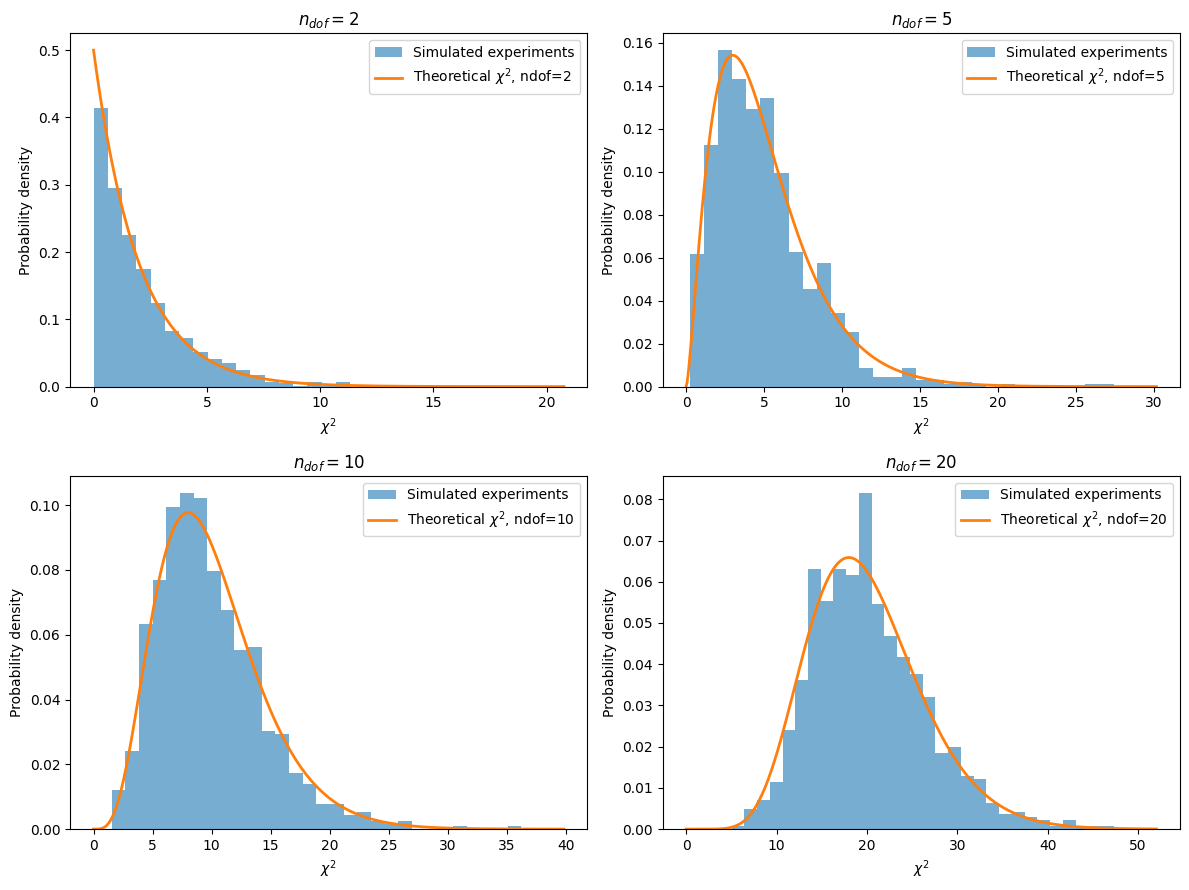

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, ndof in zip(axes.flat, ndof_values):

    # Generate the experiments again
    theory = np.arange(1, ndof + 1)
    uncertainties = np.ones(ndof)

    measurements = rng.normal(
        loc=theory,
        scale=uncertainties,
        size=(n_experiments, ndof)
    )

    # Calculate chi-square for each experiment
    chi2_values = np.sum(
        ((measurements - theory) / uncertainties)**2,
        axis=1
    )

    # Histogram of simulated chi-square values
    ax.hist(
        chi2_values,
        bins=30,
        density=True,
        alpha=0.6,
        label="Simulated experiments"
    )

    # Theoretical chi-square PDF
    x = np.linspace(
        0,
        max(chi2_values) * 1.1,
        500
    )

    ax.plot(
        x,
        chi2.pdf(x, ndof),
        linewidth=2,
        label=fr"Theoretical $\chi^2$, ndof={ndof}"
    )

    ax.set_xlabel(r"$\chi^2$")
    ax.set_ylabel("Probability density")
    ax.set_title(fr"$n_{{dof}}={ndof}$")
    ax.legend()

plt.tight_layout()
plt.show()

## Results and Interpretation

For each simulated experiment, the measurements fluctuate around their theoretical expectations according to Gaussian distributions.

After standardizing each measurement,

$$
\frac{x_i-\mu_i}{\sigma_i},
$$

we obtain independent standard normal random variables. Therefore, the calculated statistic

$$
\chi^2 =
\sum_i
\left(
\frac{x_i-\mu_i}{\sigma_i}
\right)^2
$$

is expected to follow a $\chi^2$ distribution with $n_{\mathrm{dof}}$ degrees of freedom.

The simulated distributions should therefore agree with the corresponding theoretical $\chi^2$ PDFs.

As $n_{\mathrm{dof}}$ increases, the $\chi^2$ distribution becomes less skewed and more concentrated around its mean,

$$
E[\chi^2]=n_{\mathrm{dof}},
$$

with variance

$$
\operatorname{Var}(\chi^2)=2n_{\mathrm{dof}}.
$$

Any small difference between the simulated histogram and the theoretical PDF is due to the finite number of simulated experiments ($1000$ in this case).

# Assignment 1 — Part (3)

## Question

Repeat Part (2) assuming non-Gaussian measurements.

## Theory

In Part (2), the measurements were assumed to follow Gaussian distributions. This assumption was important because, after standardization,

$$
z_i = \frac{x_i-\mu_i}{\sigma_i},
$$

each $z_i$ followed a standard normal distribution. Therefore,

$$
\chi^2 = \sum_i z_i^2
$$

followed a $\chi^2$ distribution.

Here, we repeat the same procedure using **non-Gaussian measurements**.

We consider two examples:

1. Poisson-distributed measurements
2. Exponentially distributed measurements

### 1. Poisson measurements

A Poisson-distributed measurement describes the number of events observed in a fixed interval.

The probability mass function is

$$
P(X=x)
=
\frac{\lambda^x e^{-\lambda}}{x!},
\qquad x=0,1,2,\ldots
$$

where $\lambda$ is the expected number of events.

For a Poisson distribution,

$$
E[X]=\lambda,
$$

and

$$
\operatorname{Var}(X)=\lambda.
$$

Therefore, we can use

$$
\sigma_i = \sqrt{\lambda_i}
$$

as the corresponding uncertainty and construct

$$
\chi^2 =
\sum_i
\frac{(x_i-\lambda_i)^2}{\lambda_i}.
$$

However, unlike the Gaussian case, the standardized Poisson variable

$$
\frac{x_i-\lambda_i}{\sqrt{\lambda_i}}
$$

is not exactly a standard normal random variable. Therefore, the resulting $\chi^2$ distribution is not expected to exactly follow the theoretical $\chi^2$ PDF, particularly when the expected number of events is small.

### 2. Exponential measurements

For an exponential distribution,

$$
f(x;\lambda)
=
\lambda e^{-\lambda x},
\qquad x\geq0,
$$

where $\lambda$ is the rate parameter.

Its mean and variance are

$$
E[X]=\frac{1}{\lambda},
$$

and

$$
\operatorname{Var}(X)=\frac{1}{\lambda^2}.
$$

Therefore,

$$
\sigma=\frac{1}{\lambda}.
$$

We can construct the same $\chi^2$ statistic,

$$
\chi^2 =
\sum_i
\frac{(x_i-\mu_i)^2}{\sigma_i^2},
$$

where

$$
\mu_i=\frac{1}{\lambda_i},
\qquad
\sigma_i=\frac{1}{\lambda_i}.
$$

Since the exponential distribution is strongly asymmetric and is not Gaussian, the resulting $\chi^2$ distribution is again not expected to exactly follow the standard $\chi^2$ PDF.

## Simulation Strategy

For each distribution, we will:

1. Choose a set of theoretical expectation values.
2. Generate measurements according to the chosen non-Gaussian PDF.
3. Repeat this procedure for 1000 independent experiments.
4. Calculate $\chi^2$ for each experiment using

$$
\chi^2 =
\sum_i
\frac{(x_i-\mu_i)^2}{\sigma_i^2}.
$$

5. Plot the resulting distribution of $\chi^2$.
6. Overlay the theoretical $\chi^2$ PDF with the same number of degrees of freedom.
7. Compare the simulated distribution with the $\chi^2$ expectation.

The important point is that the $\chi^2$ distribution is guaranteed in the Gaussian case because the standardized residuals are normal. For non-Gaussian measurements, this assumption is violated, so deviations from the theoretical $\chi^2$ PDF are expected.

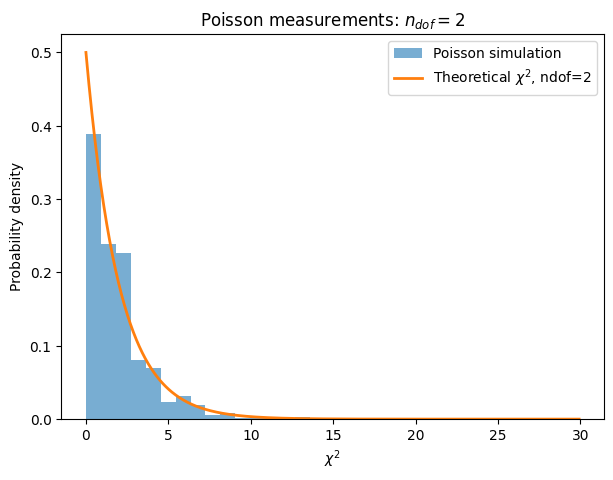

ndof = 2, mean = 2.034, expected = 2


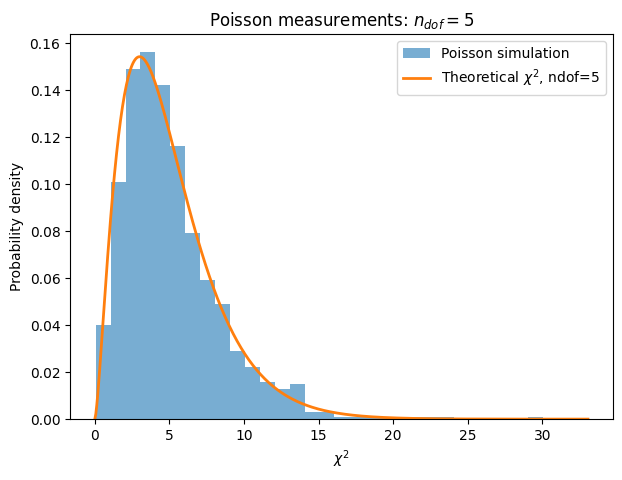

ndof = 5, mean = 5.118, expected = 5


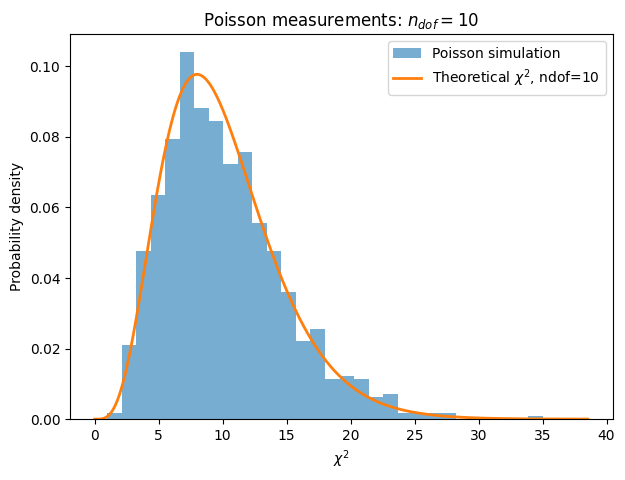

ndof = 10, mean = 10.128, expected = 10


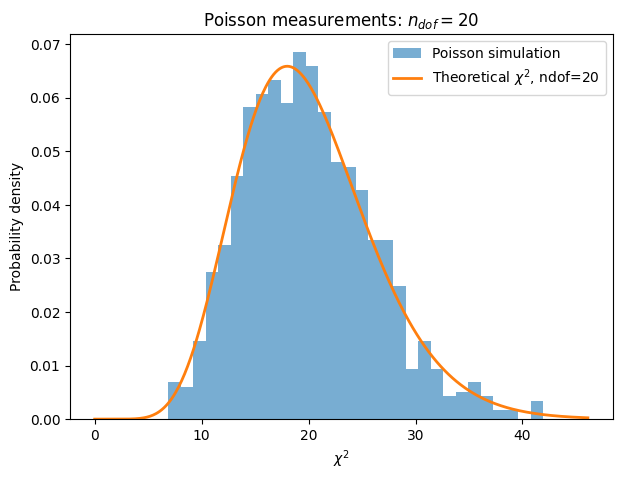

ndof = 20, mean = 20.007, expected = 20


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Number of experiments
n_experiments = 1000

# Degrees of freedom
ndof_values = [2, 5, 10, 20]

# Random number generator
rng = np.random.default_rng(42)

for ndof in ndof_values:

    # Expected number of events
    theory = np.linspace(5, 20, ndof)

    chi2_values = []

    for _ in range(n_experiments):

        # Generate Poisson measurements
        measurements = rng.poisson(theory)

        # Poisson uncertainty
        uncertainties = np.sqrt(theory)

        # Calculate chi-square
        chi2_value = np.sum(
            ((measurements - theory) / uncertainties)**2
        )

        chi2_values.append(chi2_value)

    chi2_values = np.array(chi2_values)

    # Plot
    x = np.linspace(0, max(chi2_values) * 1.1, 500)

    plt.figure(figsize=(7, 5))

    plt.hist(
        chi2_values,
        bins=30,
        density=True,
        alpha=0.6,
        label="Poisson simulation"
    )

    plt.plot(
        x,
        chi2.pdf(x, ndof),
        linewidth=2,
        label=fr"Theoretical $\chi^2$, ndof={ndof}"
    )

    plt.xlabel(r"$\chi^2$")
    plt.ylabel("Probability density")
    plt.title(fr"Poisson measurements: $n_{{dof}}={ndof}$")
    plt.legend()
    plt.show()

    print(
        f"ndof = {ndof}, "
        f"mean = {np.mean(chi2_values):.3f}, "
        f"expected = {ndof}"
    )

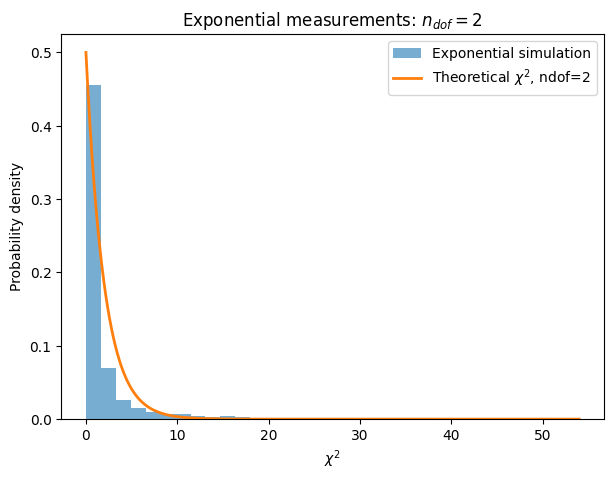

ndof = 2, mean = 2.112, expected = 2


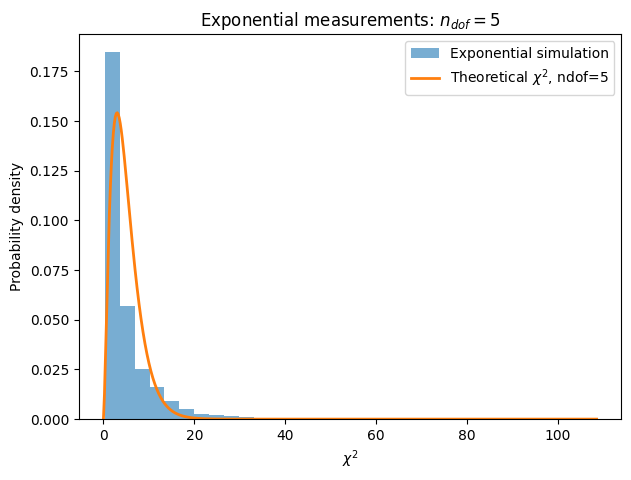

ndof = 5, mean = 5.015, expected = 5


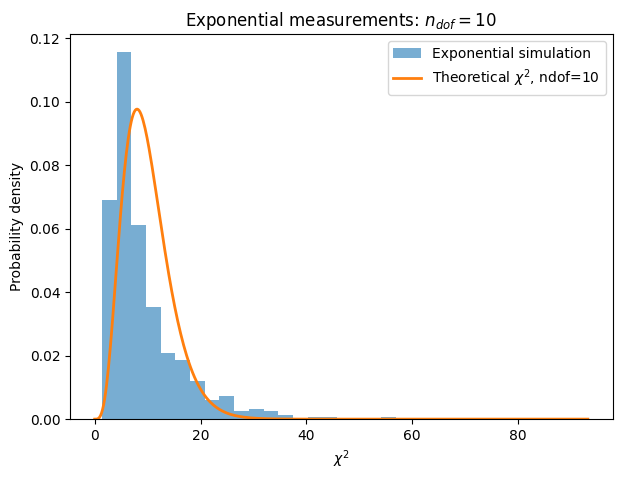

ndof = 10, mean = 9.488, expected = 10


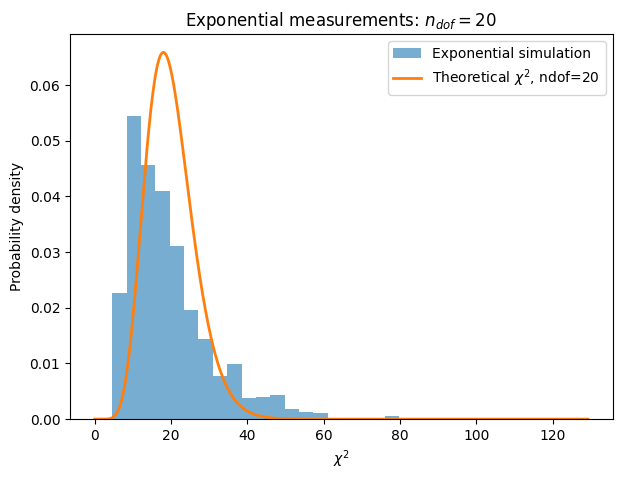

ndof = 20, mean = 19.932, expected = 20


In [7]:
#Choosing exponential distributions

for ndof in ndof_values:

    # Choose exponential rate parameters
    lambdas = np.linspace(0.5, 2.0, ndof)

    # Corresponding theoretical means
    theory = 1 / lambdas

    # Corresponding standard deviations
    uncertainties = 1 / lambdas

    chi2_values = []

    for _ in range(n_experiments):

        # Generate exponential measurements
        measurements = rng.exponential(
            scale=1 / lambdas
        )

        # Calculate chi-square
        chi2_value = np.sum(
            ((measurements - theory) / uncertainties)**2
        )

        chi2_values.append(chi2_value)

    chi2_values = np.array(chi2_values)

    # Plot
    x = np.linspace(0, max(chi2_values) * 1.1, 500)

    plt.figure(figsize=(7, 5))

    plt.hist(
        chi2_values,
        bins=30,
        density=True,
        alpha=0.6,
        label="Exponential simulation"
    )

    plt.plot(
        x,
        chi2.pdf(x, ndof),
        linewidth=2,
        label=fr"Theoretical $\chi^2$, ndof={ndof}"
    )

    plt.xlabel(r"$\chi^2$")
    plt.ylabel("Probability density")
    plt.title(fr"Exponential measurements: $n_{{dof}}={ndof}$")
    plt.legend()
    plt.show()

    print(
        f"ndof = {ndof}, "
        f"mean = {np.mean(chi2_values):.3f}, "
        f"expected = {ndof}"
    )

## Conclusion

For Gaussian measurements, the standardized residuals are independent standard normal variables, and therefore their sum of squares follows a $\chi^2$ distribution.

For the Poisson and exponential cases, the measurements are non-Gaussian. Consequently,

$$
\frac{x_i-\mu_i}{\sigma_i}
$$

is not exactly normally distributed, and the resulting statistic

$$
\chi^2 =
\sum_i
\frac{(x_i-\mu_i)^2}{\sigma_i^2}
$$

does not necessarily follow the theoretical $\chi^2$ PDF.

The deviation is particularly noticeable when the underlying distribution is strongly non-Gaussian. As the number of degrees of freedom increases, the overall distribution can become more approximately Gaussian-like due to the central limit theorem, but the standard $\chi^2$ interpretation is not exact.

This demonstrates that the usual $\chi^2$ distribution of the sum of squared standardized residuals relies on the assumption that the individual measurements are Gaussian.

# Assignment 1 — Part (4)

## Question

Do a likelihood scan of PDF parameters to some data of your choice and verify that the value of likelihood or log-likelihood is maximum at the expected correct parameter values from which the dataset is sampled.

## Theory

We choose an exponential PDF,

$$
f(x|\lambda)=\lambda e^{-\lambda x},
\qquad x\geq0,
$$

where $\lambda$ is the rate parameter.

Suppose we have $N$ independent measurements

$$
x_1,x_2,\ldots,x_N.
$$

The likelihood function is the product of the PDFs for all measurements:

$$
L(\lambda)
=
\prod_{i=1}^{N} f(x_i|\lambda).
$$

Therefore,

$$
L(\lambda)
=
\prod_{i=1}^{N}
\lambda e^{-\lambda x_i}.
$$

This can be written as

$$
L(\lambda)
=
\lambda^N
e^{-\lambda\sum_i x_i}.
$$

Since likelihoods can become extremely small for large datasets, it is more convenient to work with the log-likelihood:

$$
\ln L(\lambda)
=
N\ln\lambda
-
\lambda\sum_{i=1}^{N}x_i.
$$

The maximum-likelihood estimate is obtained by maximizing this expression.

Taking the derivative,

$$
\frac{d\ln L}{d\lambda}
=
\frac{N}{\lambda}
-
\sum_i x_i.
$$

Setting the derivative equal to zero,

$$
\frac{N}{\lambda}
=
\sum_i x_i,
$$

giving

$$
\boxed{
\hat{\lambda}
=
\frac{N}{\sum_i x_i}
=
\frac{1}{\bar{x}}
}.
$$

Therefore, if the dataset is generated using a true parameter $\lambda_{\mathrm{true}}$, the maximum of the likelihood should occur close to

$$
\boxed{\lambda_{\mathrm{true}}}.
$$

The agreement will not be exact for a finite dataset because of statistical fluctuations.

## Generating the Dataset

We first choose a true value of the exponential parameter,

$$
\lambda_{\mathrm{true}}=2.
$$

We then generate a dataset from

$$
X\sim\mathrm{Exponential}(\lambda_{\mathrm{true}}).
$$

The likelihood scan will then test different values of $\lambda$ and determine which value gives the largest log-likelihood.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# True parameter used to generate the data
lambda_true = 2.0

# Number of measurements
N = 1000

# Random number generator
rng = np.random.default_rng(42)

# Generate dataset
data = rng.exponential(
    scale=1 / lambda_true,
    size=N
)

print(f"True lambda = {lambda_true}")
print(f"Number of measurements = {N}")
print(f"Sample mean = {np.mean(data):.4f}")

# Analytical maximum-likelihood estimate
lambda_MLE = 1 / np.mean(data)

print(f"MLE estimate = {lambda_MLE:.4f}")

True lambda = 2.0
Number of measurements = 1000
Sample mean = 0.5072
MLE estimate = 1.9717


## Likelihood Scan

We now scan $\lambda$ over a range of possible values.

For each value of $\lambda$, we calculate

$$
\ln L(\lambda)
=
N\ln\lambda
-
\lambda\sum_i x_i.
$$

We then plot $\ln L(\lambda)$ as a function of $\lambda$.

The maximum of this curve gives the maximum-likelihood estimate of the parameter.

In [9]:
# Range of lambda values for the scan
lambda_values = np.linspace(0.5, 3.5, 500)

# Calculate log-likelihood for each lambda
log_likelihood = []

for lam in lambda_values:

    logL = (
        N * np.log(lam)
        - lam * np.sum(data)
    )

    log_likelihood.append(logL)

log_likelihood = np.array(log_likelihood)

# Find lambda corresponding to maximum log-likelihood
lambda_scan_MLE = lambda_values[np.argmax(log_likelihood)]

print(f"True lambda       = {lambda_true}")
print(f"Analytical MLE     = {lambda_MLE:.4f}")
print(f"Scan MLE            = {lambda_scan_MLE:.4f}")

True lambda       = 2.0
Analytical MLE     = 1.9717
Scan MLE            = 1.9729


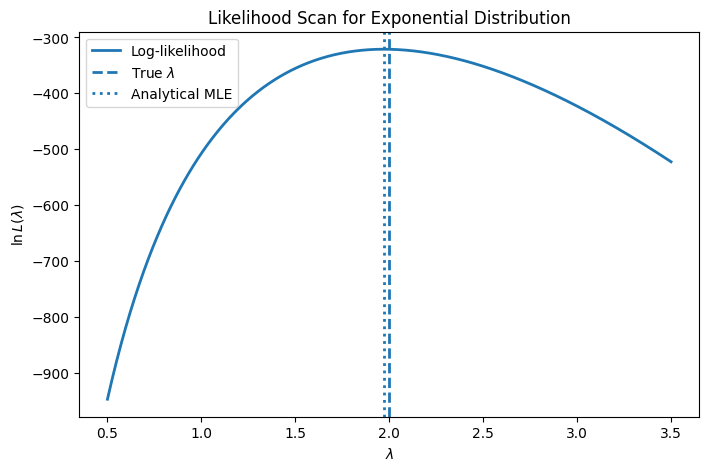

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    lambda_values,
    log_likelihood,
    linewidth=2,
    label="Log-likelihood"
)

plt.axvline(
    lambda_true,
    linestyle="--",
    linewidth=2,
    label=r"True $\lambda$"
)

plt.axvline(
    lambda_MLE,
    linestyle=":",
    linewidth=2,
    label=r"Analytical MLE"
)

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\ln L(\lambda)$")
plt.title("Likelihood Scan for Exponential Distribution")
plt.legend()

plt.show()

# Assignment 1 — Part (4)

## Question

Do a likelihood scan of the PDF parameters on some data and verify that the value of the likelihood or log-likelihood is maximum at the expected correct parameter values from which the dataset is sampled.

## Theory

We choose a Gaussian PDF and generate a dataset from it.

The Gaussian probability density function is

$$
f(x|\mu,\sigma)
=
\frac{1}{\sqrt{2\pi}\sigma}
\exp\left[
-\frac{(x-\mu)^2}{2\sigma^2}
\right].
$$

Here, the parameters we want to estimate are

$$
\mu \quad \text{and} \quad \sigma.
$$

Suppose we have $N$ independent measurements

$$
x_1,x_2,\ldots,x_N.
$$

The likelihood is the product of the individual probabilities:

$$
L(\mu,\sigma)
=
\prod_{i=1}^{N}f(x_i|\mu,\sigma).
$$

It is more convenient to work with the log-likelihood:

$$
\ln L(\mu,\sigma)
=
\sum_{i=1}^{N}\ln f(x_i|\mu,\sigma).
$$

Substituting the Gaussian PDF,

$$
\ln L(\mu,\sigma)
=
-\frac{N}{2}\ln(2\pi)
-N\ln\sigma
-\frac{1}{2\sigma^2}
\sum_{i=1}^{N}(x_i-\mu)^2.
$$

We define the negative log-likelihood (NLL) as

$$
\mathrm{NLL}(\mu,\sigma)
=
-\ln L(\mu,\sigma).
$$

Therefore,

$$
\boxed{
\mathrm{NLL}(\mu,\sigma)
=
\frac{N}{2}\ln(2\pi)
+
N\ln\sigma
+
\frac{1}{2\sigma^2}
\sum_{i=1}^{N}(x_i-\mu)^2
}
$$

The maximum likelihood estimate corresponds to the maximum of the likelihood or, equivalently,

$$
\boxed{
\text{maximum likelihood}
\Longleftrightarrow
\text{maximum log-likelihood}
\Longleftrightarrow
\text{minimum NLL}
}
$$

For a Gaussian distribution, the maximum likelihood estimates are

$$
\hat{\mu}
=
\frac{1}{N}\sum_{i=1}^{N}x_i
$$

and

$$
\hat{\sigma}^2
=
\frac{1}{N}
\sum_{i=1}^{N}(x_i-\hat{\mu})^2.
$$

Note that the MLE variance uses $N$ rather than $N-1$ in the denominator.

## Generating the Dataset

We first choose the true parameters used to generate the data:

$$
\mu_{\rm true}=5,
\qquad
\sigma_{\rm true}=2.
$$

We then generate $N$ measurements from

$$
X\sim\mathcal{N}(\mu_{\rm true},\sigma_{\rm true}^2).
$$

The likelihood scan should show that the NLL reaches its minimum close to

$$
(\mu,\sigma)=(5,2).
$$

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# True parameters
mu_true = 5.0
sigma_true = 2.0

# Number of measurements
N = 500

# Random number generator
rng = np.random.default_rng(42)

# Generate dataset
data = rng.normal(
    loc=mu_true,
    scale=sigma_true,
    size=N
)

print("True parameters:")
print(f"mu    = {mu_true}")
print(f"sigma = {sigma_true}")

True parameters:
mu    = 5.0
sigma = 2.0


In [12]:
# Maximum likelihood estimates

mu_mle = np.mean(data)

sigma_mle = np.sqrt(
    np.mean((data - mu_mle)**2)
)

print("Maximum Likelihood Estimates:")
print(f"mu_hat    = {mu_mle:.4f}")
print(f"sigma_hat = {sigma_mle:.4f}")

Maximum Likelihood Estimates:
mu_hat    = 4.9737
sigma_hat = 1.9179


## 2D Negative Log-Likelihood Scan

Instead of directly calculating the MLE, we now scan over a range of possible values of $\mu$ and $\sigma$.

For every point $(\mu,\sigma)$ in the parameter space, we calculate

$$
\mathrm{NLL}(\mu,\sigma)
=
-\ln L(\mu,\sigma).
$$

This gives us a two-dimensional NLL surface.

The best-fit parameters correspond to the point where

$$
\boxed{\mathrm{NLL}(\mu,\sigma)\ \text{is minimum}.}
$$

Therefore, we expect the minimum of the 2D scan to occur close to

$$
(\mu,\sigma)=(\mu_{\rm true},\sigma_{\rm true}).
$$

In [13]:
from scipy.stats import norm

# Define parameter ranges
mu_values = np.linspace(3.5, 6.5, 150)
sigma_values = np.linspace(1.0, 3.5, 150)

# Create 2D grid
MU, SIGMA = np.meshgrid(mu_values, sigma_values)

# Calculate NLL for every point
NLL = np.zeros_like(MU)

for i in range(len(sigma_values)):
    for j in range(len(mu_values)):

        mu = MU[i, j]
        sigma = SIGMA[i, j]

        # Log-likelihood
        logL = np.sum(
            norm.logpdf(data, loc=mu, scale=sigma)
        )

        # Negative log-likelihood
        NLL[i, j] = -logL

# Find minimum NLL
min_index = np.unravel_index(
    np.argmin(NLL),
    NLL.shape
)

best_mu = MU[min_index]
best_sigma = SIGMA[min_index]

print(f"Best-fit mu    = {best_mu:.4f}")
print(f"Best-fit sigma = {best_sigma:.4f}")
print(f"Minimum NLL    = {NLL[min_index]:.4f}")

Best-fit mu    = 4.9698
Best-fit sigma = 1.9228
Minimum NLL    = 1035.1013


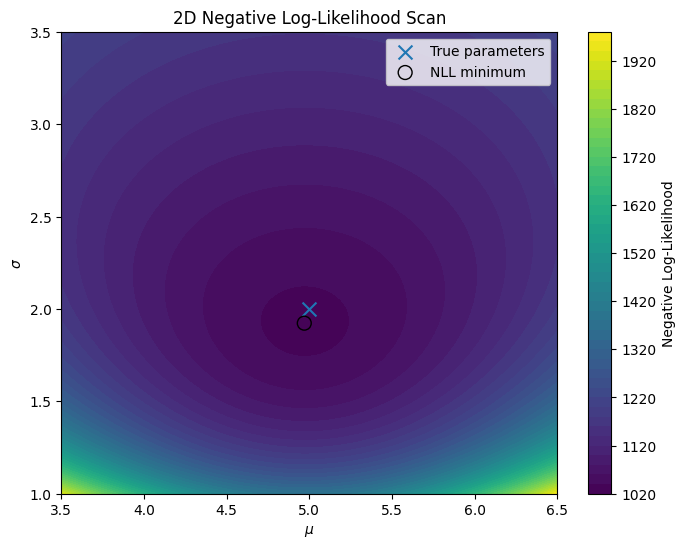

In [14]:
plt.figure(figsize=(8, 6))

contour = plt.contourf(
    MU,
    SIGMA,
    NLL,
    levels=50
)

plt.colorbar(contour, label="Negative Log-Likelihood")

plt.scatter(
    mu_true,
    sigma_true,
    marker="x",
    s=100,
    label="True parameters"
)

plt.scatter(
    best_mu,
    best_sigma,
    marker="o",
    facecolors="none",
    edgecolors="black",
    s=100,
    label="NLL minimum"
)

plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma$")
plt.title("2D Negative Log-Likelihood Scan")
plt.legend()

plt.show()

## NLL Relative to the Minimum

For visualization, it is useful to subtract the minimum NLL:

$$
\Delta\mathrm{NLL}
=
\mathrm{NLL}
-
\mathrm{NLL}_{\min}.
$$

Thus,

$$
\boxed{\Delta\mathrm{NLL}=0}
$$

at the best-fit point.

This makes the location of the preferred parameter values easier to identify.

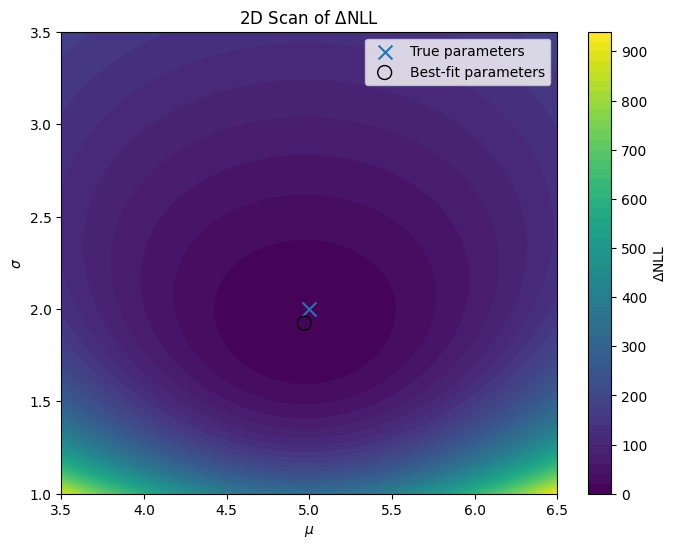

In [15]:
# NLL relative to minimum
delta_NLL = NLL - np.min(NLL)

plt.figure(figsize=(8, 6))

contour = plt.contourf(
    MU,
    SIGMA,
    delta_NLL,
    levels=50
)

plt.colorbar(contour, label=r"$\Delta$NLL")

plt.scatter(
    mu_true,
    sigma_true,
    marker="x",
    s=100,
    label="True parameters"
)

plt.scatter(
    best_mu,
    best_sigma,
    marker="o",
    facecolors="none",
    edgecolors="black",
    s=100,
    label="Best-fit parameters"
)

plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma$")
plt.title(r"2D Scan of $\Delta$NLL")
plt.legend()

plt.show()

## Conclusion

The dataset was generated using

$$
\mu_{\rm true}=5,
\qquad
\sigma_{\rm true}=2.
$$

A two-dimensional scan of the negative log-likelihood over $(\mu,\sigma)$ was performed.

The likelihood is maximized when the NLL is minimized:

$$
\boxed{
L_{\max}
\Longleftrightarrow
(\ln L)_{\max}
\Longleftrightarrow
\mathrm{NLL}_{\min}
}
$$

The minimum of the NLL scan occurs close to the true values used to generate the dataset,

$$
\boxed{
(\hat{\mu},\hat{\sigma})
\approx
(\mu_{\rm true},\sigma_{\rm true})
}.
$$

The small difference between the fitted and true values is due to statistical fluctuations in the finite dataset.

This verifies the principle of maximum likelihood estimation: the parameter values that best describe the observed data are those that maximize the likelihood.